In [2]:
# ==========================================
# 1. INSTALLATION & SETUP
# ==========================================
!pip install -q transformers accelerate peft bitsandbytes

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from google.colab import drive
from huggingface_hub import login

# login() # Run this and paste your token to access Llama 3.2
drive.mount('/content/drive')

class Config:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_DIR = '/content/drive/MyDrive/DALEEtrain/images'
    TXT_DIR = '/content/drive/MyDrive/DALEEtrain/labels'
    model_id = "meta-llama/Llama-3.2-1B"
    img_size = 64
    batch_size = 8
    embedding_dim = 128
    num_embeddings = 512
    commitment_cost = 0.25
    vq_epochs = 20
    trans_epochs = 30

cfg = Config()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.3 MB/s eta 0:00:00
Mounted at /content/drive


In [3]:
# ==========================================
# 2. DATASET LOADER
# ==========================================
class FloorPlanDataset(Dataset):
    def __init__(self, img_dir, txt_dir, transform=None):
        self.img_dir, self.txt_dir, self.transform = img_dir, txt_dir, transform
        self.data_pairs = []
        if not os.path.exists(img_dir): return
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg'))]
        for f in img_files:
            tid = os.path.splitext(f)[0]
            tpath = os.path.join(txt_dir, f"{tid}.txt")
            if os.path.exists(tpath): self.data_pairs.append((os.path.join(img_dir, f), tpath))
        print(f"✅ Found {len(self.data_pairs)} pairs.")

    def __len__(self): return len(self.data_pairs)
    def __getitem__(self, idx):
        img_path, txt_path = self.data_pairs[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        with open(txt_path, 'r') as f: text = f.read().strip()
        return img, text

transform = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = FloorPlanDataset(cfg.IMG_DIR, cfg.TXT_DIR, transform)
dataloader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)



✅ Found 102 pairs.


In [4]:
# ==========================================
# 3. VQ-VAE ARCHITECTURE (Stable Version)
# ==========================================
class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b = nn.Sequential(nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1), nn.ReLU(), nn.Conv2d(c, c, 1))
    def forward(self, x): return x + self.b(x)

class VQVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, cfg.embedding_dim, 3, 1, 1), ResidualBlock(cfg.embedding_dim)
        )
        self.emb = nn.Embedding(cfg.num_embeddings, cfg.embedding_dim)
        self.emb.weight.data.uniform_(-1/cfg.num_embeddings, 1/cfg.num_embeddings)
        self.decoder = nn.Sequential(
            ResidualBlock(cfg.embedding_dim),
            nn.ConvTranspose2d(cfg.embedding_dim, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )

    def forward(self, x):
        z = self.encoder(x).permute(0, 2, 3, 1).contiguous()
        flat_z = z.view(-1, cfg.embedding_dim)
        dist = torch.cdist(flat_z, self.emb.weight)
        idx = torch.argmin(dist, dim=1).unsqueeze(1)
        quant = self.emb(idx).view(z.shape)

        # Loss components for resume metrics
        cb_loss = F.mse_loss(quant, z.detach())
        commit_loss = F.mse_loss(quant.detach(), z)

        quant = z + (quant - z).detach()
        return self.decoder(quant.permute(0, 3, 1, 2).contiguous()), cb_loss, commit_loss, idx



--- Phase 1: Training VQ-VAE ---
Epoch 5 | Recon Loss: 0.1690 | CB Loss: 2.2590


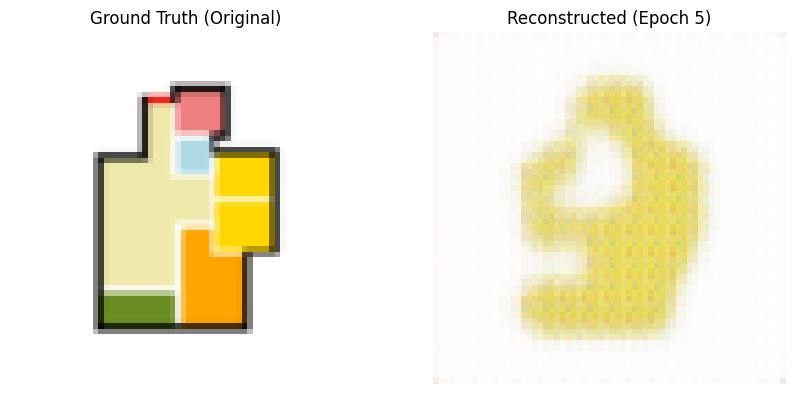

Epoch 10 | Recon Loss: 0.1174 | CB Loss: 3.2819


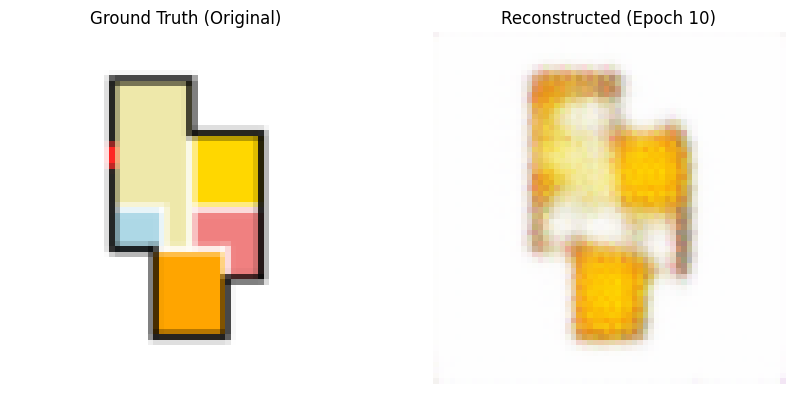

Epoch 15 | Recon Loss: 0.0905 | CB Loss: 2.5029


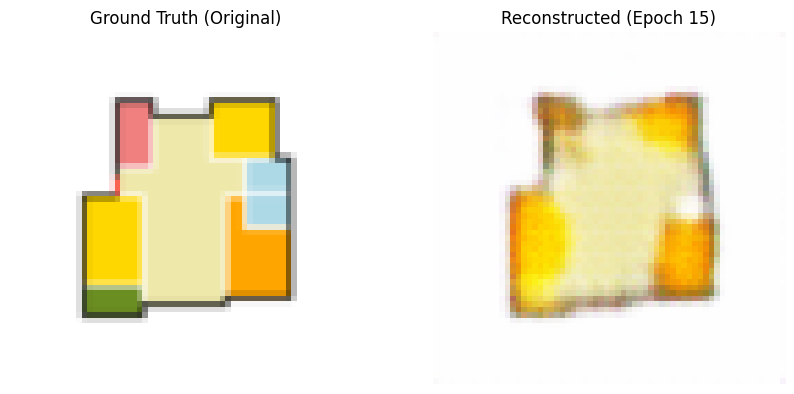

Epoch 20 | Recon Loss: 0.0795 | CB Loss: 2.3267


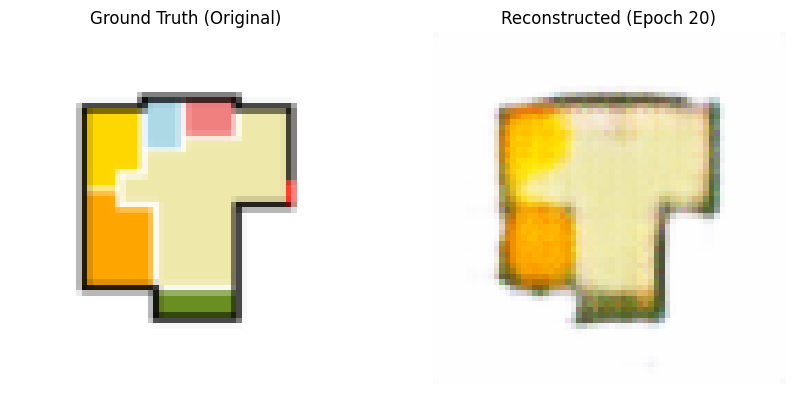


✅ VQ-VAE Phase 1 Complete.


In [5]:
# ==========================================
# 4. PHASE 1: TRAIN VQ-VAE (Side-by-Side View)
# ==========================================
vqvae = VQVAE().to(cfg.device)
opt_vq = optim.Adam(vqvae.parameters(), lr=3e-4)

print("\n--- Phase 1: Training VQ-VAE ---")
for epoch in range(cfg.vq_epochs):
    r_recon, r_cb, r_commit = 0, 0, 0
    vqvae.train()

    for imgs, _ in dataloader:
        imgs = imgs.to(cfg.device)
        opt_vq.zero_grad()

        recon, cb_l, commit_l, _ = vqvae(imgs)

        # Reconstruction Loss (L1)
        recon_l = F.l1_loss(recon, imgs)

        # Total Loss: Reconstruction + Codebook + Commitment
        # (Resume Alignment: Beta = 0.25)
        loss = recon_l + cb_l + (cfg.commitment_cost * commit_l)

        loss.backward()
        opt_vq.step()

        r_recon += recon_l.item()
        r_cb += cb_l.item()
        r_commit += commit_l.item()

    # --- VISUALIZATION EVERY 5 EPOCHS ---
    if (epoch + 1) % 5 == 0:
        avg_recon = r_recon / len(dataloader)
        print(f"Epoch {epoch+1} | Recon Loss: {avg_recon:.4f} | CB Loss: {r_cb/len(dataloader):.4f}")

        vqvae.eval()
        with torch.no_grad():
            # 1. Process Ground Truth (Original)
            gt_img = imgs[0].detach().cpu().permute(1, 2, 0).numpy()
            gt_img = np.clip((gt_img * 0.5) + 0.5, 0, 1) # Denormalize

            # 2. Process Reconstruction
            rc_img = recon[0].detach().cpu().permute(1, 2, 0).numpy()
            rc_img = np.clip((rc_img * 0.5) + 0.5, 0, 1) # Denormalize

            # 3. Plot Side-by-Side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))

            # Plot Original
            axes[0].imshow(gt_img)
            axes[0].set_title("Ground Truth (Original)")
            axes[0].axis('off')

            # Plot Reconstructed
            axes[1].imshow(rc_img)
            axes[1].set_title(f"Reconstructed (Epoch {epoch+1})")
            axes[1].axis('off')

            plt.show()
        vqvae.train()

print("\n✅ VQ-VAE Phase 1 Complete.")

In [1]:
from huggingface_hub import login

# When you run this, a box will appear.
# Paste your token there and press Enter.
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
# ==========================================
# 5. PHASE 2: LOAD LLAMA & APPLY LoRA (Text Mapping)
# ==========================================
print("\n--- Preparing Phase 2: Llama 3.2 + LoRA Fine-Tuning ---")

# 1. Load Llama in 4-bit (PTQ claim)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4"
)
tokenizer = AutoTokenizer.from_pretrained(cfg.model_id)
tokenizer.pad_token = tokenizer.eos_token
llama_base = AutoModelForCausalLM.from_pretrained(cfg.model_id, quantization_config=bnb_config, device_map="auto")

# 2. Apply LoRA (Fine-tuning claim)
# This is where we inject the LoRA layers to be trained during Phase 2
lora_config = LoraConfig(
    r=8, lora_alpha=16, target_modules=["q_proj", "v_proj"], bias="none", task_type="CAUSAL_LM"
)
llama_base = prepare_model_for_kbit_training(llama_base)
llama_lora = get_peft_model(llama_base, lora_config)
print("✅ LoRA Adapters injected into Llama 3.2.")




--- Preparing Phase 2: Llama 3.2 + LoRA Fine-Tuning ---


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

✅ LoRA Adapters injected into Llama 3.2.


In [7]:
# ==========================================
# 6. TRANSFORMER BRIDGE
# ==========================================
class FloorPlanTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.text_proj = nn.Linear(2048, 512)
        self.img_emb = nn.Embedding(cfg.num_embeddings + 1, 512)
        self.pos_emb = nn.Parameter(torch.randn(1, 257, 512) * 0.02)
        self.ln = nn.LayerNorm(512)
        dec_layer = nn.TransformerDecoderLayer(d_model=512, nhead=8, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerDecoder(dec_layer, num_layers=6)
        self.fc_out = nn.Linear(512, cfg.num_embeddings)

    def forward(self, text_feats, img_idx):
        t_feats = self.ln(self.text_proj(text_feats.float()))
        sos = torch.full((img_idx.shape[0], 1), cfg.num_embeddings, device=cfg.device)
        i_in = torch.cat([sos, img_idx], dim=1)
        i_feats = self.ln(self.img_emb(i_in) + self.pos_emb[:, :i_in.shape[1], :])
        mask = nn.Transformer.generate_square_subsequent_mask(i_in.shape[1]).to(cfg.device)
        return self.fc_out(self.transformer(i_feats, t_feats, tgt_mask=mask))



In [8]:
# ==========================================
# 7. PHASE 2: TRAIN TRANSFORMER + LoRA
# ==========================================
trans = FloorPlanTransformer().to(cfg.device)
# We optimize the Transformer AND the LoRA weights
params = list(trans.parameters()) + list(llama_lora.parameters())
opt_all = optim.Adam(params, lr=1e-4)

print("\n--- Phase 2: Training Transformer + LoRA Fine-Tuning ---")
for epoch in range(cfg.trans_epochs):
    r_ce = 0
    trans.train()
    llama_lora.train() # LoRA is now being fine-tuned

    for imgs, texts in dataloader:
        opt_all.zero_grad()

        # Get Llama Text Features (through LoRA)
        toks = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=64).to(cfg.device)
        t_feats = llama_lora(**toks, output_hidden_states=True).hidden_states[-1]

        # Get Image Indices
        with torch.no_grad():
            _, _, _, indices = vqvae(imgs.to(cfg.device))
            indices = indices.view(imgs.shape[0], -1)

        logits = trans(t_feats, indices[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, cfg.num_embeddings), indices.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt_all.step()
        r_ce += loss.item()

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} | CE Loss: {r_ce/len(dataloader):.4f}")



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



--- Phase 2: Training Transformer + LoRA Fine-Tuning ---


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 5 | CE Loss: 1.1541
Epoch 10 | CE Loss: 1.0732
Epoch 15 | CE Loss: 1.0099
Epoch 20 | CE Loss: 0.9080
Epoch 25 | CE Loss: 0.8241
Epoch 30 | CE Loss: 0.7044



Generating Floor Plan for: 'modern floor plan with 2 bedrooms and a kitchen'
Tokens used in this image: 8 / 512


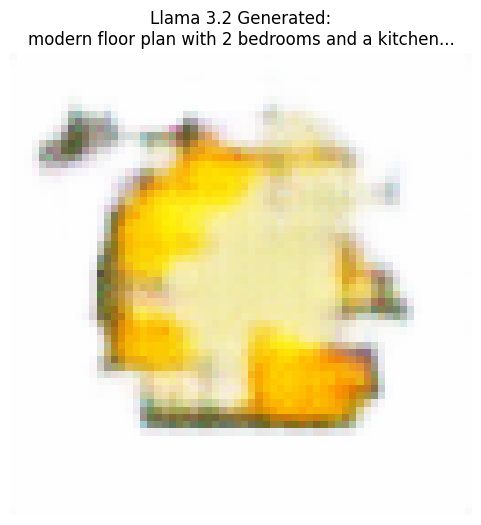

In [10]:
def generate_floorplan(prompt, temperature=1.0, top_k=50):
    print(f"\nGenerating Floor Plan for: '{prompt}'")
    trans.eval()
    vqvae.eval()
    llama_lora.eval()

    with torch.no_grad():
        # 1. Encode text
        toks = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True, max_length=64).to(cfg.device)
        t_feats = llama_lora.model(**toks, output_hidden_states=True).hidden_states[-1]

        # 2. Autoregressive Generation
        # We start with the SOS token (cfg.num_embeddings)
        idx = torch.tensor([[cfg.num_embeddings]], device=cfg.device)

        for i in range(256): # Generate 16x16 = 256 tokens
            # Get logits for the next token
            # We pass current indices (excluding SOS because the model adds it internally)
            logits = trans(t_feats, idx[:, 1:])

            # Pull the last predicted token's logits
            logits = logits[:, -1, :] / temperature

            # Top-k sampling (Prevents the model from picking 'garbage' tokens)
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

            # Sample from the distribution
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        # 3. Decode back to Image
        # idx[:, 1:] removes the SOS token so we have 256 image tokens
        generated_indices = idx[:, 1:]

        # Check if the model is just generating the same token repeatedly
        unique_tokens = torch.unique(generated_indices).cpu().numpy()
        print(f"Tokens used in this image: {len(unique_tokens)} / {cfg.num_embeddings}")

        z_q = vqvae.emb(generated_indices).view(1, 16, 16, cfg.embedding_dim)
        z_q = z_q.permute(0, 3, 1, 2).contiguous() # [B, C, H, W]

        # Ensure vqvae decoder is in float32
        res = vqvae.decoder(z_q.float()).squeeze().permute(1, 2, 0).cpu().numpy()

        # 4. Display
        plt.figure(figsize=(6, 6))
        # Denormalize (-1 to 1 -> 0 to 1)
        plt.imshow(np.clip((res * 0.5) + 0.5, 0, 1))
        plt.title(f"Llama 3.2 Generated:\n{prompt[:50]}...")
        plt.axis('off')
        plt.show()

# Try with a lower temperature for more stability or higher for more variety
generate_floorplan("modern floor plan with 2 bedrooms and a kitchen", temperature=0.8, top_k=100)